In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, os, warnings
warnings.filterwarnings("ignore")

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack, csr_matrix

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_PATH   = "../data/processed/severity_data.csv"
OUT_MODEL   = "../models/resolution_classifier.pkl"
OUT_ENCODER = "../models/resolution_label_encoder.pkl"
OUT_FIG     = "../outputs/figures"
os.makedirs(OUT_FIG, exist_ok=True)

MIN_CLASS_FREQ = 200

print("Setup complete")

Setup complete


In [2]:
df = pd.read_csv(DATA_PATH)
print(f"Shape: {df.shape}")

print("Raw company_response distribution:")
for resp, cnt in df["company_response"].value_counts().items():
    print(f"  {cnt:>6,} {resp}")

freq_map = df["company_response"].value_counts()
df["response_class"] = df["company_response"].apply(
    lambda r: r if freq_map.get(r, 0) >= MIN_CLASS_FREQ else "Other"
)

le = LabelEncoder()
df["response_label"] = le.fit_transform(df["response_class"])

joblib.dump(le, OUT_ENCODER)
print(f"Label encoder saved: {OUT_ENCODER}")
print(f"Final classes ({len(le.classes_)}):")
for i, cls in enumerate(le.classes_):
    n = (df["response_class"] == cls).sum()
    print(f"  {i} {cls:<50s} {n:>6,}")

Shape: (17181, 18)
Raw company_response distribution:
  12,585 Closed with explanation
   3,606 Closed with non-monetary relief
     876 Closed with monetary relief
      70 Untimely response
      44 Closed
Label encoder saved: ../models/resolution_label_encoder.pkl
Final classes (4):
  0 Closed with explanation                            12,585
  1 Closed with monetary relief                           876
  2 Closed with non-monetary relief                     3,606
  3 Other                                                 114


In [3]:
tfidf_narrative = TfidfVectorizer(max_features=20_000, ngram_range=(1, 2),
                                  sublinear_tf=True, min_df=5)
tfidf_issue     = TfidfVectorizer(max_features=5_000,  ngram_range=(1, 2),
                                  sublinear_tf=True, min_df=3)

X_narr  = tfidf_narrative.fit_transform(df["text_processed"].fillna(""))
X_issue = tfidf_issue.fit_transform(df["issue"].fillna(""))

sentiment_map = {"negative": -1, "neutral": 0, "positive": 1}
dense_features = np.column_stack([
    df["cluster"].values,
    df["compound"].values,
    df["severity_score"].fillna(3).values,
    df["word_count"].values,
    df["sentiment"].map(sentiment_map).fillna(0).values,
])
X_dense = csr_matrix(dense_features)

X = hstack([X_narr, X_issue, X_dense])
y = df["response_label"].values

print(f"Feature matrix: {X.shape}")
print(f"  TF-IDF narrative: {X_narr.shape[1]}")
print(f"  TF-IDF issue:     {X_issue.shape[1]}")
print(f"  Dense numeric:    {dense_features.shape[1]}")

Feature matrix: (17181, 20382)
  TF-IDF narrative: 20000
  TF-IDF issue:     377
  Dense numeric:    5


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

clf = LogisticRegression(
    C=1.0,
    max_iter=1000,
    class_weight="balanced",
    solver="lbfgs",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print(f"Test accuracy: {(y_pred == y_test).mean():.4f}")
print(classification_report(y_test, y_pred,
                            target_names=le.classes_, digits=4))

cv_scores = cross_val_score(clf, X_train, y_train, cv=5,
                            scoring="f1_macro", n_jobs=-1)
print(f"5-fold CV F1 (macro): {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")

joblib.dump({"clf": clf,
             "tfidf_narrative": tfidf_narrative,
             "tfidf_issue": tfidf_issue}, OUT_MODEL)
print(f"Model bundle saved: {OUT_MODEL}")

Test accuracy: 0.5214
                                 precision    recall  f1-score   support

        Closed with explanation     0.8449    0.4631    0.5983      2518
    Closed with monetary relief     0.2033    0.8400    0.3274       175
Closed with non-monetary relief     0.4065    0.6546    0.5016       721
                          Other     0.0405    0.3043    0.0714        23

                       accuracy                         0.5214      3437
                      macro avg     0.3738    0.5655    0.3747      3437
                   weighted avg     0.7149    0.5214    0.5607      3437

5-fold CV F1 (macro): 0.3955 +/- 0.0151
Model bundle saved: ../models/resolution_classifier.pkl


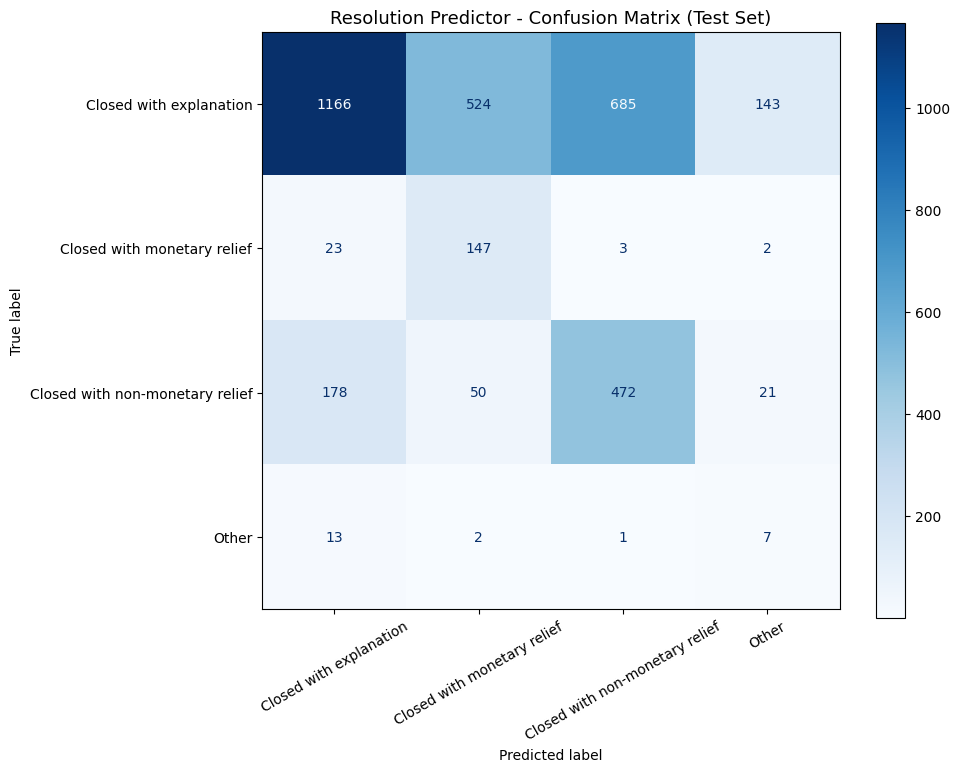

In [5]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=ax, colorbar=True, cmap="Blues", xticks_rotation=30)
ax.set_title("Resolution Predictor - Confusion Matrix (Test Set)", fontsize=13)
plt.tight_layout()
plt.savefig(f"{OUT_FIG}/08_resolution_cm.png", dpi=150, bbox_inches="tight")
plt.show()

In [6]:
def predict_resolution(narrative: str, issue: str,
                       cluster: int, compound: float,
                       severity: int = 3, word_count: int = 100) -> dict:
    bundle = joblib.load(OUT_MODEL)
    le     = joblib.load(OUT_ENCODER)

    x_narr  = bundle["tfidf_narrative"].transform([narrative])
    x_issue = bundle["tfidf_issue"].transform([issue])
    x_dense = csr_matrix([[cluster, compound, severity, word_count,
                           -1 if compound <= -0.05 else (1 if compound >= 0.05 else 0)]])
    x = hstack([x_narr, x_issue, x_dense])

    probs = bundle["clf"].predict_proba(x)[0]
    results = {le.classes_[i]: round(float(p), 4) for i, p in enumerate(probs)}
    return dict(sorted(results.items(), key=lambda x: x[1], reverse=True))


sample = df.iloc[0]
preds = predict_resolution(
    narrative=sample["text_processed"],
    issue=sample["issue"],
    cluster=int(sample["cluster"]),
    compound=float(sample["compound"]),
)
print("Sample resolution probabilities:")
for cls, prob in preds.items():
    print(f"  {prob:.4f} {cls}")

Sample resolution probabilities:
  0.5360 Closed with non-monetary relief
  0.3774 Closed with explanation
  0.0865 Other
  0.0001 Closed with monetary relief
